In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# プロットのスタイル設定
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

Fig 3 Data Loaded.


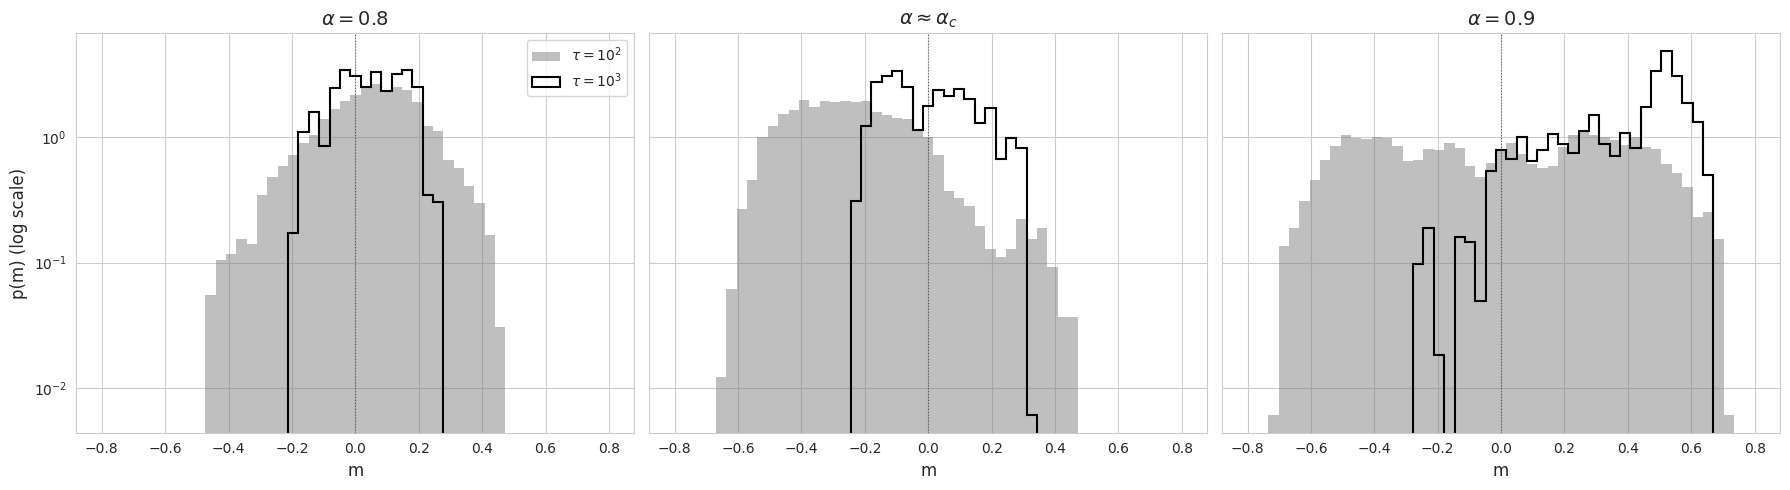

In [4]:
# データ読み込み
try:
    df3 = pd.read_csv("aco_fig3_data.csv")
    print("Fig 3 Data Loaded.")
except FileNotFoundError:
    print("Error: 'aco_fig3_data.csv' not found.")

# パラメータ
target_alphas = [0.8, 0.83515, 0.9]
titles = [r"$\alpha=0.8$", r"$\alpha \approx \alpha_c$", r"$\alpha=0.9$"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
bins = np.linspace(-0.8, 0.8, 50)

for i, alpha_target in enumerate(target_alphas):
    ax = axes[i]
    # alpha値でフィルタリング (浮動小数点誤差を許容)
    subset = df3[np.isclose(df3['alpha'], alpha_target, atol=1e-4)]
    
    # tau=100 (Filled Histogram)
    data_100 = subset[subset['tau'] == 100]['m_value']
    ax.hist(data_100, bins=bins, alpha=0.5, label=r'$\tau=10^2$', 
            density=True, log=True, color='gray', edgecolor='none')
    
    # tau=1000 (Step Histogram)
    data_1000 = subset[subset['tau'] == 1000]['m_value']
    ax.hist(data_1000, bins=bins, alpha=1.0, label=r'$\tau=10^3$', 
            density=True, log=True, color='black', histtype='step', linewidth=1.5)
    
    ax.set_title(titles[i], fontsize=14)
    ax.set_xlabel("m", fontsize=12)
    ax.axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.5) # m=0

axes[0].set_ylabel("p(m) (log scale)", fontsize=12)
axes[0].legend()
plt.tight_layout()
plt.show()

Fig 4 Data Loaded.


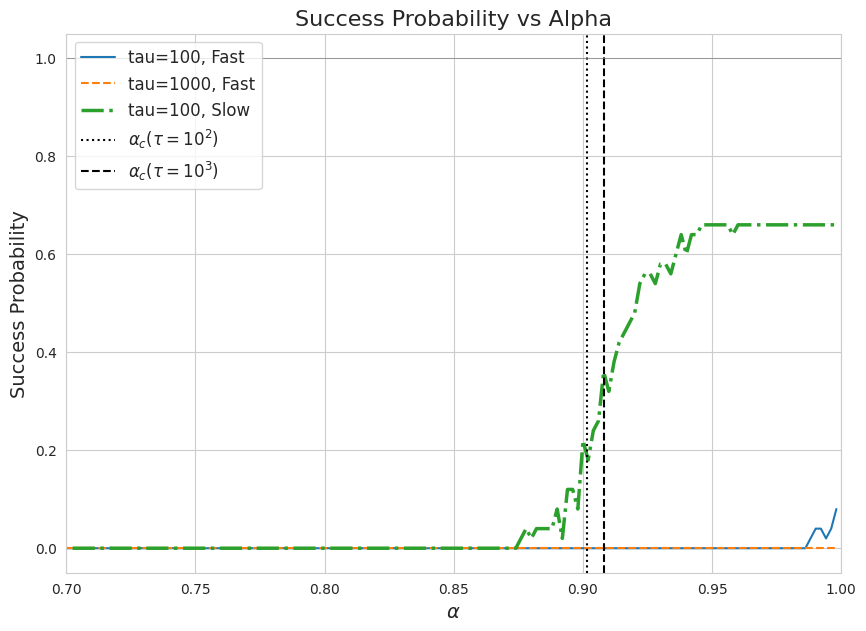

In [10]:
# データ読み込み
try:
    df4 = pd.read_csv("aco_fig4_data.csv")
    print("Fig 4 Data Loaded.")
except FileNotFoundError:
    print("Error: 'aco_fig4_data.csv' not found.")

plt.figure(figsize=(10, 7))

# 理論的な alpha_c の計算 (J=0.1, tau=100)
J = 0.1

def alpha_c(tau):
    term1 = tau * (J + 1)
    return (np.sqrt(term1**2 + 4*tau) - term1) / 2

# プロット
labels = df4['label'].unique()
linestyles = ['-', '--', '-.', ':']

for i, label in enumerate(labels):
    subset = df4[df4['label'] == label].sort_values(by='alpha')
    
    # 論文のスタイルに似せる
    ls = linestyles[i % len(linestyles)]
    lw = 2.5 if "Slow" in label else 1.5
    
    plt.plot(subset['alpha'], subset['success_prob'], 
             label=label, linestyle=ls, linewidth=lw)

# 補助線
plt.axvline(x=alpha_c(100), color='black', linestyle=':', label=r'$\alpha_c (\tau=10^2)$')
plt.axvline(x=alpha_c(1000), color='black', linestyle='--', label=r'$\alpha_c (\tau=10^3)$')
plt.axhline(y=1.0, color='gray', linestyle='-', linewidth=0.5)

plt.xlabel(r"$\alpha$", fontsize=14)
plt.ylabel("Success Probability", fontsize=14)
plt.title("Success Probability vs Alpha", fontsize=16)
plt.xlim(0.7, 1.0) # 変化が起きる領域を拡大
plt.ylim(-0.05, 1.05)
plt.legend(fontsize=12, loc='upper left')
plt.show()